# Declaration of Originality

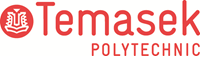

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Ho Seng Kiat Victor (2400293C)
* Tutorial Group                : PC05 
* Tutor						    : Kian Eng Ong 
* Submission Date               : 


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [350]:
## Import libraries
import pandas as pd
import numpy as np
import plotly 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [351]:
## Read *.csv file into pandas DataFrame
FILE_PATH = 'ResaleFlatPrice.csv'
df = pd.read_csv(FILE_PATH)
df


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
222213,2026-01,YISHUN,4 ROOM,334B,YISHUN ST 31,04 TO 06,92.0,Model A,2015,88 years 11 months,585000.0
222214,2026-01,YISHUN,4 ROOM,336C,YISHUN ST 31,10 TO 12,92.0,Model A,2015,88 years 11 months,620888.0
222215,2026-01,YISHUN,4 ROOM,479B,YISHUN ST 42,01 TO 03,93.0,Model A,2021,94 years 04 months,575000.0
222216,2026-01,YISHUN,4 ROOM,754,YISHUN ST 72,10 TO 12,84.0,Simplified,1985,58 years 09 months,490000.0


## 2.2 Summary Statistics

In [352]:
## Understand the type of variable for each column
df.dtypes

month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object

In [353]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [354]:
## Unique values in each column
df.nunique()

month                   109
town                     26
flat_type                 7
block                  2745
street_name             577
storey_range             17
floor_area_sqm          187
flat_model               21
lease_commence_date      57
remaining_lease         694
resale_price           4553
dtype: int64

In [355]:
## Summary statistics for numerical columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,222218.000000,222218.000000,2.222180e+05
mean,96.767227,1996.436121,5.245420e+05
std,24.020346,14.302552,1.866274e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.850000e+05
50%,93.000000,1997.000000,4.920000e+05
75%,112.000000,2012.000000,6.300000e+05
max,366.700000,2022.000000,1.658888e+06


In [356]:
## Display random sample of 10 rows from the DataFrame to get a feel of the data
df.sample(10)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
34010,2018-08,QUEENSTOWN,4 ROOM,19,DOVER CRES,16 TO 18,92.0,Model A,2003,84 years 01 month,638000.0
193748,2024-04,WOODLANDS,5 ROOM,881,WOODLANDS ST 82,04 TO 06,125.0,Improved,1996,71 years 03 months,665000.0
98086,2021-05,PUNGGOL,4 ROOM,266B,PUNGGOL WAY,04 TO 06,92.0,Model A,2015,93 years 01 month,468000.0
90246,2021-02,BEDOK,4 ROOM,773,BEDOK RESERVOIR VIEW,07 TO 09,105.0,Premium Apartment,2000,78 years 11 months,492000.0
114744,2021-12,BUKIT PANJANG,EXECUTIVE,542,JELAPANG RD,04 TO 06,142.0,Maisonette,1999,76 years 08 months,800000.0
185993,2024-12,PUNGGOL,5 ROOM,107D,EDGEFIELD PLAINS,07 TO 09,110.0,Improved,2003,77 years 04 months,660000.0
188572,2024-05,SENGKANG,5 ROOM,319A,ANCHORVALE DR,13 TO 15,110.0,Improved,2002,77 years 05 months,718000.0
183559,2024-04,PASIR RIS,5 ROOM,102,PASIR RIS ST 12,13 TO 15,122.0,Improved,1988,63 years 09 months,703800.0
147212,2023-10,BUKIT BATOK,4 ROOM,171,BT BATOK WEST AVE 8,10 TO 12,103.0,Model A,1985,60 years 06 months,530000.0
102687,2021-07,PUNGGOL,3 ROOM,314B,PUNGGOL WAY,07 TO 09,68.0,Premium Apartment,2017,95 years 03 months,395000.0


In [357]:
## Dropping colums that are pure identifiers and is not useful for analysis of resale price
df = df.drop(columns = ['block','street_name'], axis=1)

## Perform Ordinal Encoding on flat_type column
flat_type_map = {
    '1 ROOM': 1,
    '2 ROOM': 2,
    '3 ROOM': 3,
    '4 ROOM': 4,
    '5 ROOM': 5,
    'EXECUTIVE': 6,
    'MULTI-GENERATION': 7
}

df['flat_type_ordinal'] = df['flat_type'].map(flat_type_map)

## Convert storey_range like "10 TO 12" → 11
df['storey_avg'] = (
    df['storey_range']
    .astype(str)
    .str.extract(r'(\d+)\s*TO\s*(\d+)')
    .astype(float)
    .mean(axis=1)
)

## Convert remaining_lease like "78 years 6 months" → 78.5
df['remaining_lease_years'] = (
    df['remaining_lease']
    .astype(str)
    .str.extract(r'(?:(\d+)\s*years?)?\s*(?:(\d+)\s*months?)?')
    .fillna(0)
    .astype(float)
    .apply(lambda x: x[0] + x[1] / 12, axis=1)
)

## Convert month to datetime format
df['year'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce').dt.year

## Convert floor_area_sqm and lease_commence_date to numeric for EDA plots/correlation
df['floor_area_sqm'] = pd.to_numeric(df['floor_area_sqm'], errors='coerce')
df['lease_commence_date'] = pd.to_numeric(df['lease_commence_date'], errors='coerce')


## Drop original column after conversion
df = df.drop(columns=['month','remaining_lease','storey_range'], errors='ignore')

df


,town,flat_type,floor_area_sqm,flat_model,lease_commence_date,resale_price,flat_type_ordinal,storey_avg,remaining_lease_years,year
0,ANG MO KIO,2 ROOM,44.0,Improved,1979,232000.0,2,11.0,61.333333,2017
1,ANG MO KIO,3 ROOM,67.0,New Generation,1978,250000.0,3,2.0,60.583333,2017
2,ANG MO KIO,3 ROOM,67.0,New Generation,1980,262000.0,3,2.0,62.416667,2017
3,ANG MO KIO,3 ROOM,68.0,New Generation,1980,265000.0,3,5.0,62.083333,2017
4,ANG MO KIO,3 ROOM,67.0,New Generation,1980,265000.0,3,2.0,62.416667,2017
...,...,...,...,...,...,...,...,...,...,...
222213,YISHUN,4 ROOM,92.0,Model A,2015,585000.0,4,5.0,88.916667,2026
222214,YISHUN,4 ROOM,92.0,Model A,2015,620888.0,4,11.0,88.916667,2026
222215,YISHUN,4 ROOM,93.0,Model A,2021,575000.0,4,2.0,94.333333,2026
222216,YISHUN,4 ROOM,84.0,Simplified,1985,490000.0,4,11.0,58.750000,2026


In [358]:
df.dtypes

town                      object
flat_type                 object
floor_area_sqm           float64
flat_model                object
lease_commence_date        int64
resale_price             float64
flat_type_ordinal          int64
storey_avg               float64
remaining_lease_years    float64
year                       int32
dtype: object

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

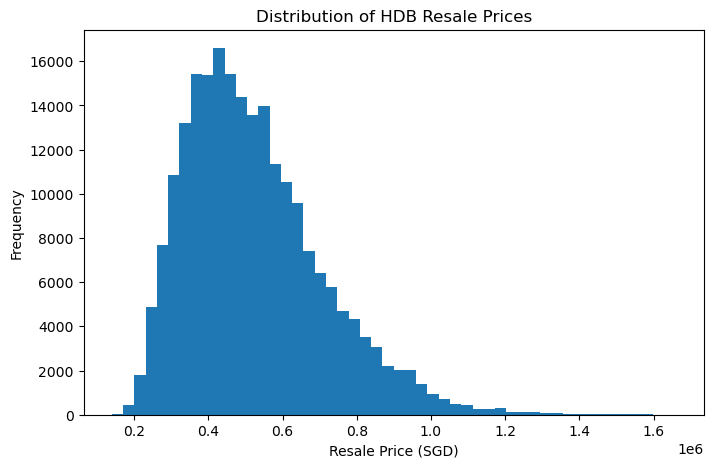

In [359]:
## Understanding distribution of HDB resale prices
plt.figure(figsize=(8,5))
plt.hist(df['resale_price'], bins=50)
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Frequency')
plt.title('Distribution of HDB Resale Prices')
plt.show()


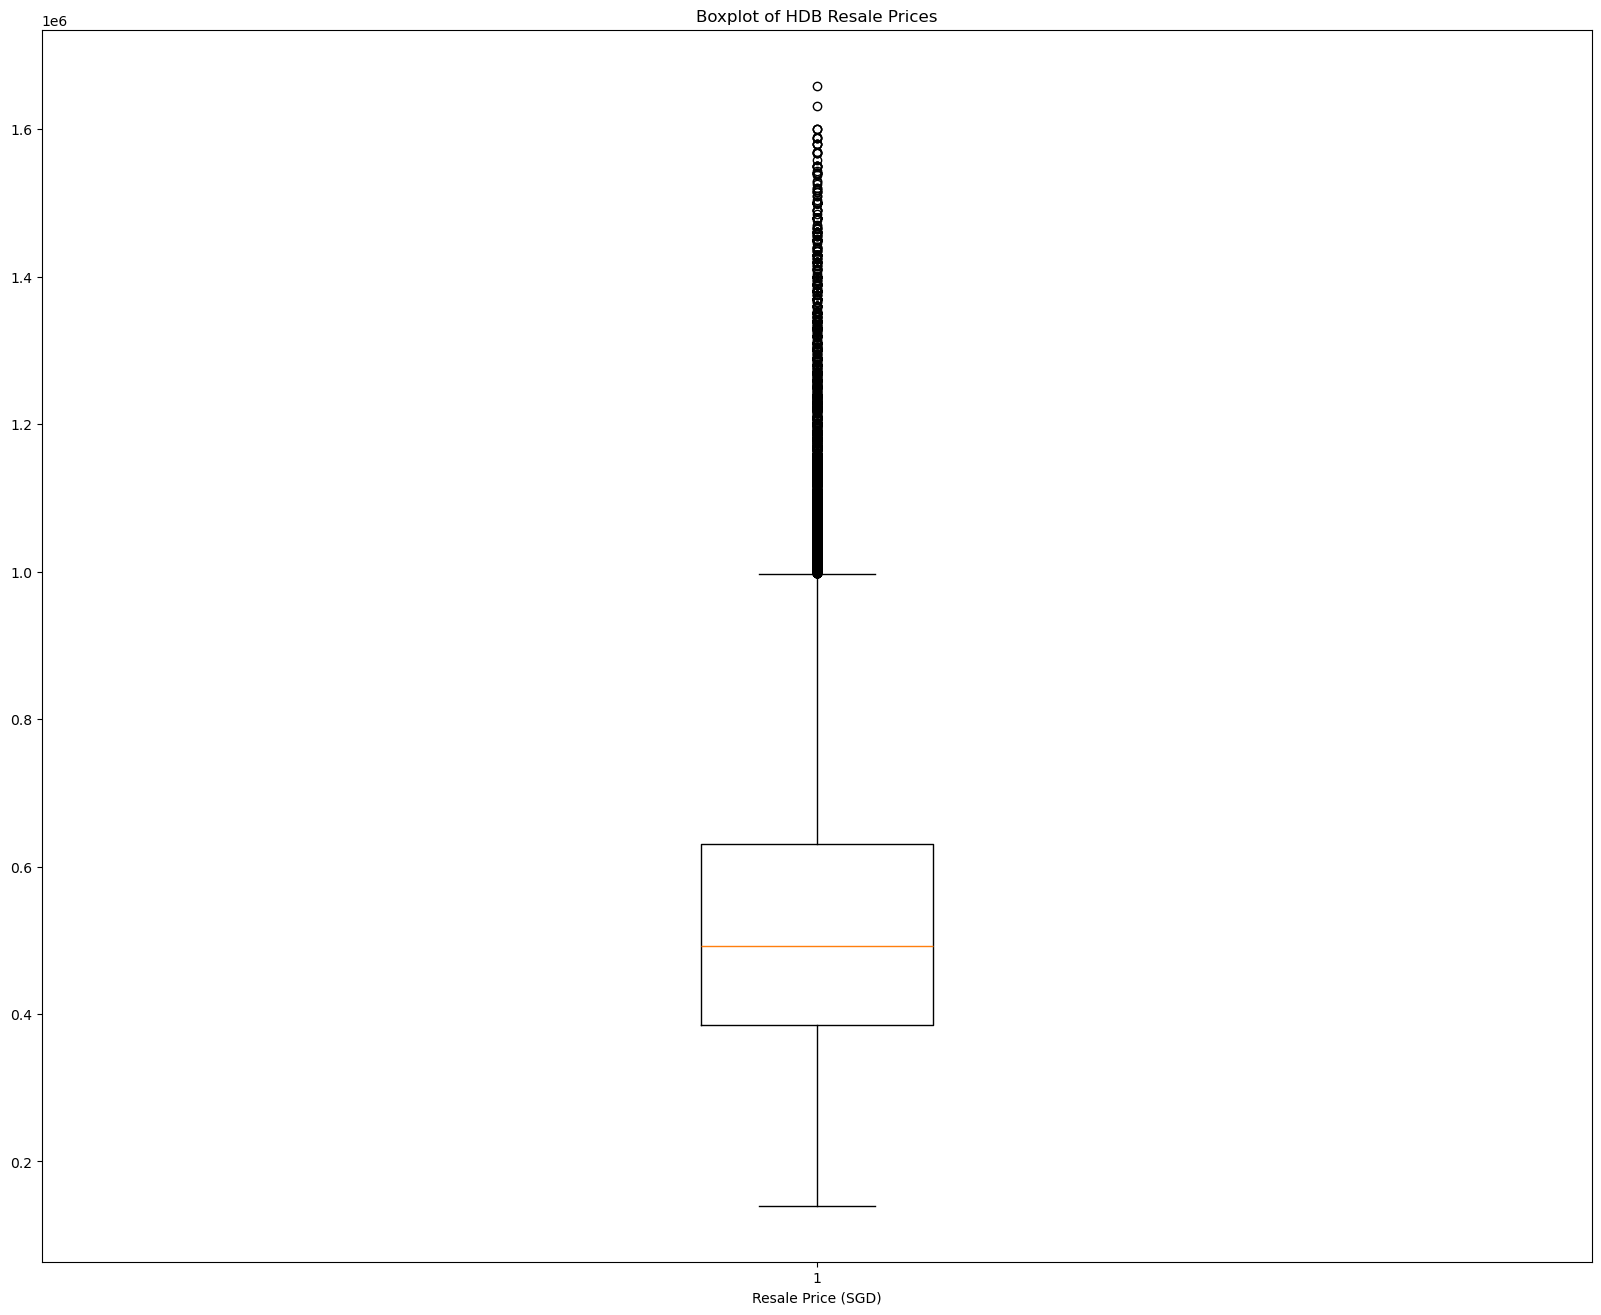

In [360]:
## Boxplot to identify outliers in resale prices
plt.figure(figsize=(20,16))
plt.boxplot(df['resale_price'])
plt.xlabel('Resale Price (SGD)')
plt.title('Boxplot of HDB Resale Prices')
plt.show()


In [361]:
## Summary statistics + quantiles for resale prices
df['resale_price'].quantile([0, 0.25, 0.5, 0.75, 1])


0.00     140000.0
0.25     385000.0
0.50     492000.0
0.75     630000.0
1.00    1658888.0
Name: resale_price, dtype: float64

In [362]:
df['resale_price'].quantile([0.01, 0.05, 0.5, 0.95, 0.99])


0.01     230000.0
0.05     280000.0
0.50     492000.0
0.95     880000.0
0.99    1070000.0
Name: resale_price, dtype: float64

### 2.3.1.2 Understanding distribution of features

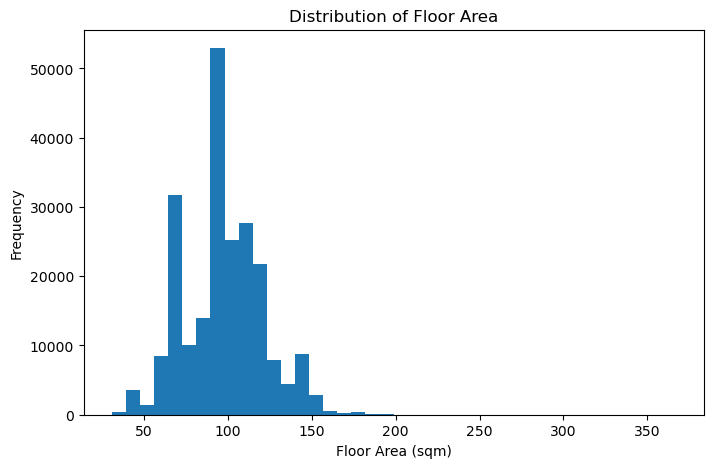

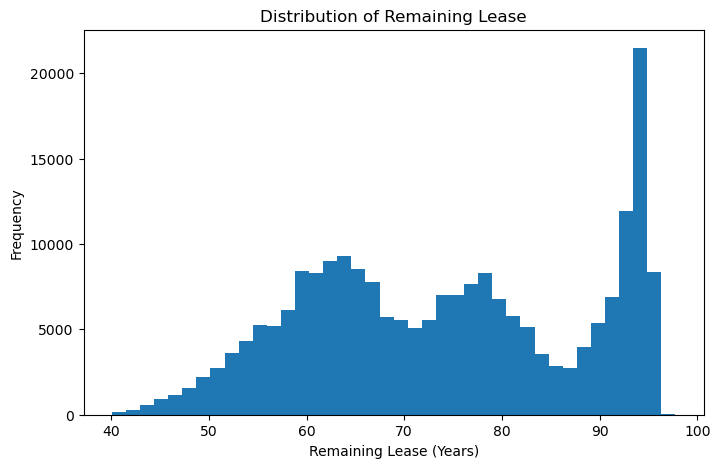

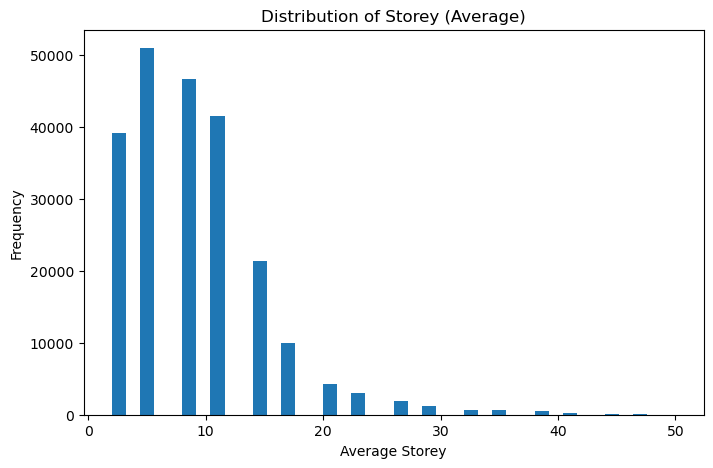

In [363]:
## Understanding distribution of Floor Area
plt.figure(figsize=(8,5))
plt.hist(df['floor_area_sqm'], bins=40)
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Frequency')
plt.title('Distribution of Floor Area')
plt.show()
## Understanding distribution of Remaining Lease
plt.figure(figsize=(8,5))
plt.hist(df['remaining_lease_years'], bins=40)
plt.xlabel('Remaining Lease (Years)')
plt.ylabel('Frequency')
plt.title('Distribution of Remaining Lease')
plt.show()
## Understanding distribution of Storey (Average)
plt.figure(figsize=(8,5))
plt.hist(df['storey_avg'].dropna(), bins=40)
plt.xlabel('Average Storey')
plt.ylabel('Frequency')
plt.title('Distribution of Storey (Average)')
plt.show()



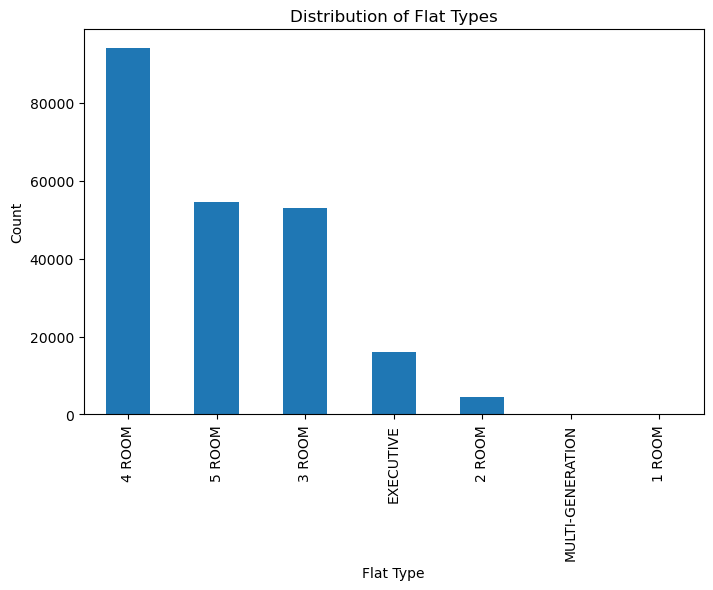

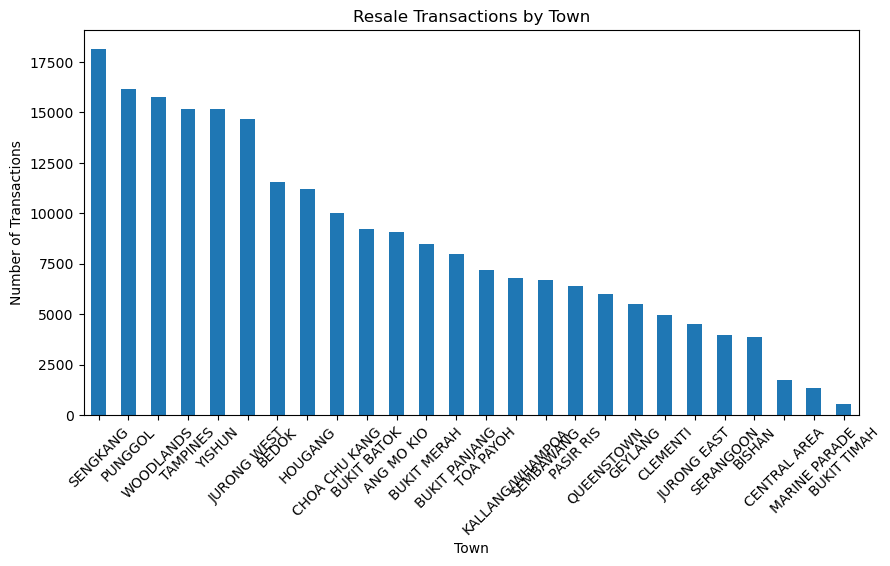

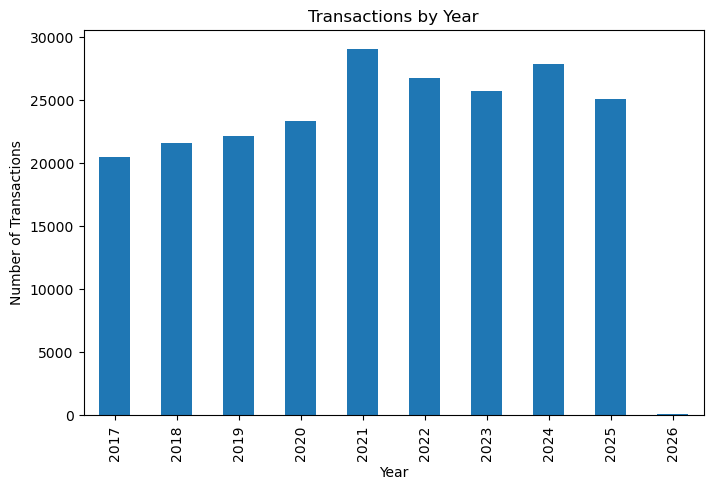

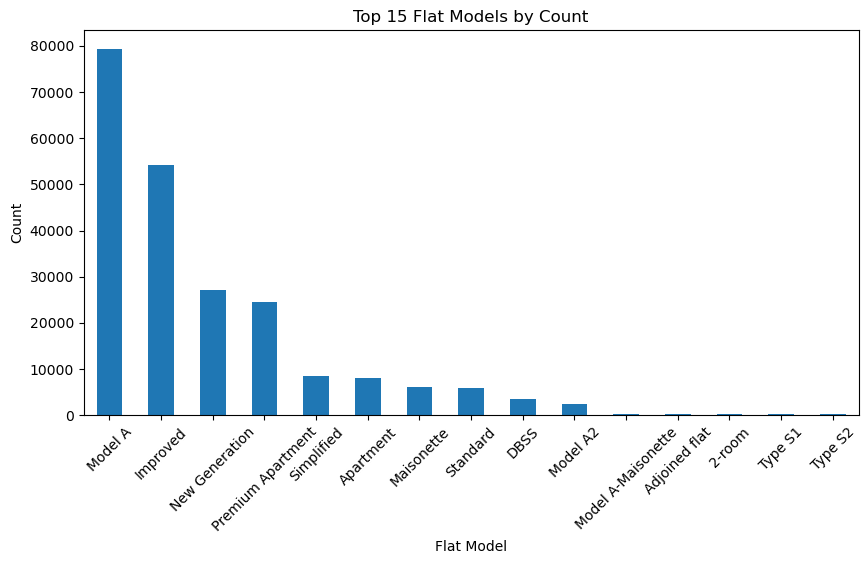

In [364]:
##Understanding distribution of Flat Types
df['flat_type'].value_counts().plot(kind='bar', figsize=(8,5))
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.title('Distribution of Flat Types')
plt.show()
##Understanding distribution of Towns
df['town'].value_counts().plot(kind='bar', figsize=(10,5))
plt.xlabel('Town')
plt.ylabel('Number of Transactions')
plt.title('Resale Transactions by Town')
plt.xticks(rotation=45)
plt.show()
##Understanding distribution of Years
plt.figure(figsize=(8,5))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.title('Transactions by Year')
plt.show()
##Understanding distribution of Flat Models
top_n = 15
plt.figure(figsize=(10,5))
df['flat_model'].value_counts().head(top_n).plot(kind='bar')
plt.xlabel('Flat Model')
plt.ylabel('Count')
plt.title(f'Top {top_n} Flat Models by Count')
plt.xticks(rotation=45)
plt.show()


In [365]:
print("\nTown counts:\n", df['town'].value_counts())


Town counts:
 town
SENGKANG           18166
PUNGGOL            16167
WOODLANDS          15759
TAMPINES           15158
YISHUN             15148
JURONG WEST        14660
BEDOK              11569
HOUGANG            11227
CHOA CHU KANG      10033
BUKIT BATOK         9227
ANG MO KIO          9073
BUKIT MERAH         8479
BUKIT PANJANG       7970
TOA PAYOH           7212
KALLANG/WHAMPOA     6797
SEMBAWANG           6720
PASIR RIS           6400
QUEENSTOWN          6010
GEYLANG             5494
CLEMENTI            4943
JURONG EAST         4515
SERANGOON           3954
BISHAN              3891
CENTRAL AREA        1737
MARINE PARADE       1367
BUKIT TIMAH          542
Name: count, dtype: int64


In [366]:
print("Flat type counts:\n", df['flat_type'].value_counts())
print("Flat model counts:\n", df['flat_model'].value_counts())
print("\nTown counts (bottom 10):\n", df['town'].value_counts().tail(10))


Flat type counts:
 flat_type
4 ROOM              94164
5 ROOM              54534
3 ROOM              52908
EXECUTIVE           15945
2 ROOM               4503
MULTI-GENERATION       84
1 ROOM                 80
Name: count, dtype: int64
Flat model counts:
 flat_model
Model A                   79413
Improved                  54302
New Generation            27207
Premium Apartment         24521
Simplified                 8524
Apartment                  7986
Maisonette                 6119
Standard                   5961
DBSS                       3561
Model A2                   2513
Model A-Maisonette          388
Adjoined flat               378
2-room                      365
Type S1                     360
Type S2                     186
Premium Apartment Loft      121
Terrace                     114
Multi Generation             84
3Gen                         66
Improved-Maisonette          30
Premium Maisonette           19
Name: count, dtype: int64

Town counts (bottom 10):
 town
PA

### 2.3.2 Understanding relationship between variables

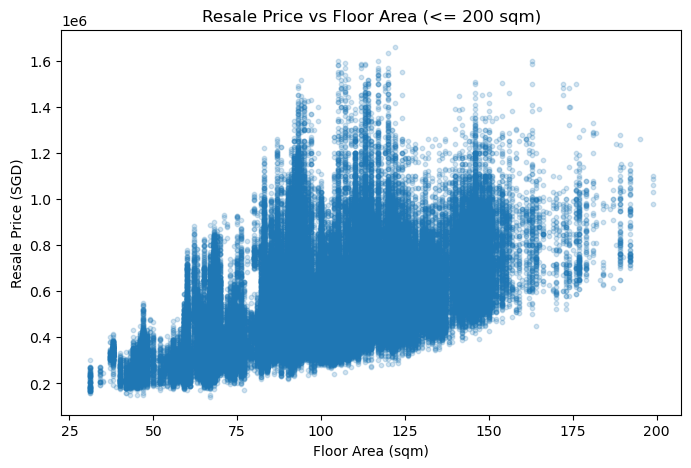

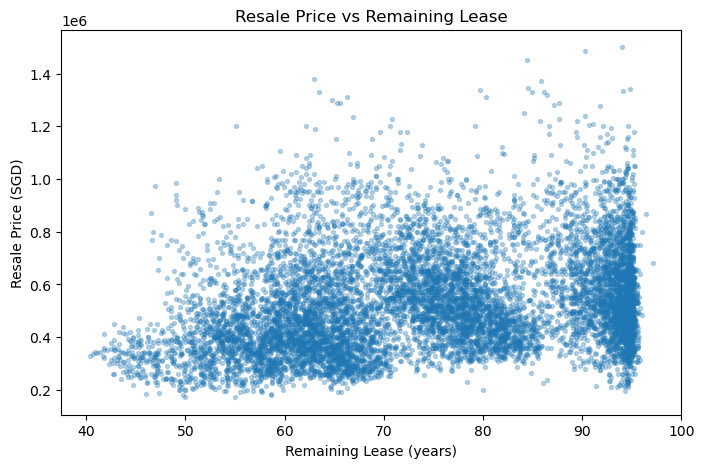

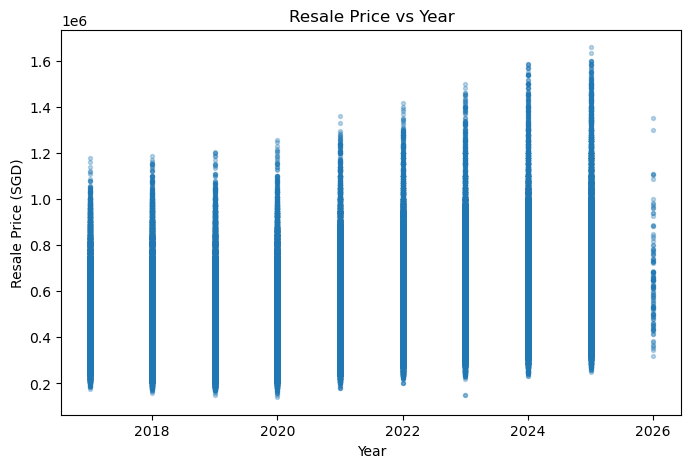

In [367]:
## Understanding relationship between Resale Price and Floor Area
df_zoom = df[df['floor_area_sqm'] <= 200]

plt.figure(figsize=(8,5))
plt.scatter(df_zoom['floor_area_sqm'], df_zoom['resale_price'], alpha=0.2, s=10)
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Floor Area (<= 200 sqm)')
plt.show()


## Understanding relationship between Resale Price and Remaining Lease
df_sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(df_sample['remaining_lease_years'], df_sample['resale_price'], alpha=0.3, s=8)
plt.xlabel('Remaining Lease (years)')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Remaining Lease')
plt.show()

## Understanding relationship between Resale Price and Year
plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['resale_price'], alpha=0.3, s=8)
plt.xlabel('Year')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Year')
plt.show()


<Figure size 900x500 with 0 Axes>

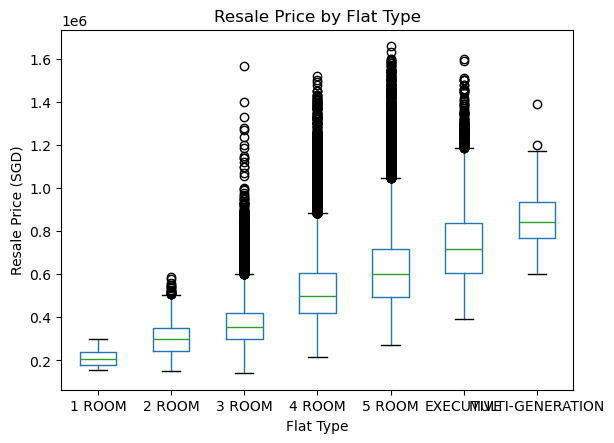

<Figure size 1200x500 with 0 Axes>

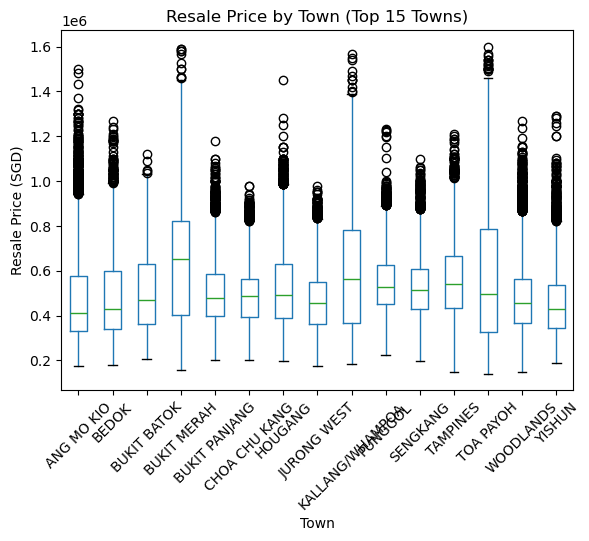

In [368]:
## Understanding relationship between Resale Price and Flat Type using Boxplot
plt.figure(figsize=(9,5))
df.boxplot(column='resale_price', by='flat_type', grid=False)
plt.xlabel('Flat Type')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price by Flat Type')
plt.suptitle('')
plt.show()

## Understanding relationship between Resale Price and Town using Boxplot
top_towns = df['town'].value_counts().head(15).index
df_top = df[df['town'].isin(top_towns)]

plt.figure(figsize=(12,5))
df_top.boxplot(column='resale_price', by='town', grid=False)
plt.xlabel('Town')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price by Town (Top 15 Towns)')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()


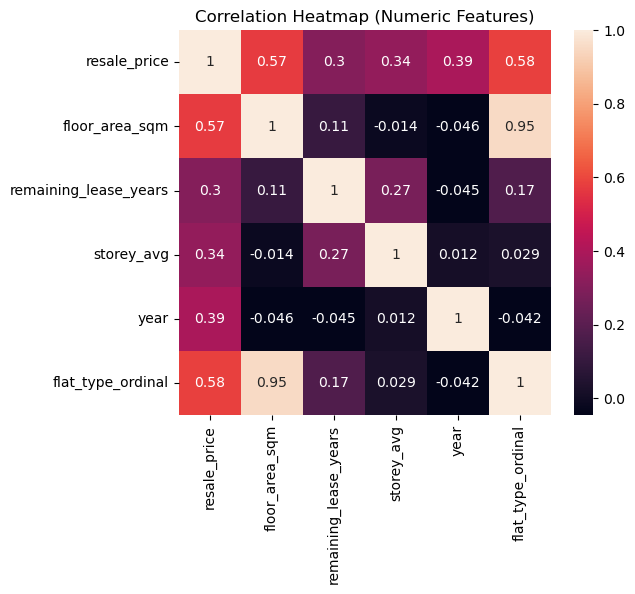

In [369]:
numeric_cols = [
    'resale_price',
    'floor_area_sqm',
    'remaining_lease_years',
    'storey_avg',
    'year',
    'flat_type_ordinal'
]

plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


# 3. Data Preparation

## 3.1 Data Cleaning

In [370]:
## Clean data
## Perform one-hot encoding on town
df = pd.get_dummies(df, columns=['town'], drop_first=True)

col_y = 'resale_price'
y = df[col_y]

col_ireelevant = ['resale_price', 'flat_type', 'flat_model']
x = df.drop(col_ireelevant, axis=1)
x

,floor_area_sqm,lease_commence_date,flat_type_ordinal,storey_avg,remaining_lease_years,year,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,...,town_PASIR RIS,town_PUNGGOL,town_QUEENSTOWN,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN
0,44.0,1979,2,11.0,61.333333,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,67.0,1978,3,2.0,60.583333,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,67.0,1980,3,2.0,62.416667,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,68.0,1980,3,5.0,62.083333,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,67.0,1980,3,2.0,62.416667,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222213,92.0,2015,4,5.0,88.916667,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222214,92.0,2015,4,11.0,88.916667,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222215,93.0,2021,4,2.0,94.333333,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222216,84.0,1985,4,11.0,58.750000,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## 3.2 Train-Test Split

In [371]:
## Split data into train set and test set
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=2025
)
linr = LinearRegression()
linr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 4. Modelling

### 4.2 Train Model

In [372]:
## Initialise and train model
y_pred = linr.predict(X_test)


# 5. Model Evaluation

In [373]:
## Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print('Linear RegressionL MAE:', mean_absolute_error(y_test, y_pred))
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred))
print('Linear Regression RMSE:', root_mean_squared_error(y_test, y_pred))
print('Linear Regression R^2:', r2_score(y_test, y_pred))


Linear RegressionL MAE: 55471.42527435147
Linear Regression MSE: 5218507651.182551
Linear Regression RMSE: 72239.23899919317
Linear Regression R^2: 0.8478927571011473


In [379]:
x

,floor_area_sqm,lease_commence_date,flat_type_ordinal,storey_avg,remaining_lease_years,year,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,...,town_PASIR RIS,town_PUNGGOL,town_QUEENSTOWN,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN
0,44.0,1979,2,11.0,61.333333,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,67.0,1978,3,2.0,60.583333,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,67.0,1980,3,2.0,62.416667,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,68.0,1980,3,5.0,62.083333,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,67.0,1980,3,2.0,62.416667,2017,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222213,92.0,2015,4,5.0,88.916667,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222214,92.0,2015,4,11.0,88.916667,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222215,93.0,2021,4,2.0,94.333333,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222216,84.0,1985,4,11.0,58.750000,2026,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [382]:
## New data
new_data = pd.DataFrame([
    {"town": "ANG MO KIO",  "floor_area_sqm": 67,  "storey_avg": 5,  "lease_commence_date": 1980,  "year": 2022, "flat_type_ord": 3},
    {"town": "BEDOK",       "floor_area_sqm": 92,  "storey_avg": 10, "lease_commence_date": 1978,  "year": 2023, "flat_type_ord": 4},
    {"town": "JURONG WEST", "floor_area_sqm": 110, "storey_avg": 12, "lease_commence_date": 1985,  "year": 2024, "flat_type_ord": 5},
    {"town": "BUKIT MERAH", "floor_area_sqm": 115, "storey_avg": 20, "lease_commence_date": 1955,  "year": 2021, "flat_type_ord": 5},
    {"town": "PUNGGOL",     "floor_area_sqm": 130, "storey_avg": 15, "lease_commence_date": 1990,  "year": 2024, "flat_type_ord": 6},
])

## Predict
new_data_encoded = pd.get_dummies(new_data, columns=['town'], drop_first=True)

## Align columns to training features (x is your training feature dataframe)
new_data_encoded = new_data_encoded.reindex(columns=x.columns, fill_value=0)

## Predict
new_pred = linr.predict(new_data_encoded)

pd.DataFrame({
    "Predicted_Resale_Price": new_pred
})


,Predicted_Resale_Price
0,9.104540e+05
1,1.005321e+06
2,1.090936e+06
3,8.583358e+05
4,1.280150e+06


## Iterative model development


In [ ]:
## Further feature engineering / feature selection

## Classify flat_model into categories: 'standard', 'premium', 'special'
## Merge lease_commence_date and remaiing